In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
content = pd.read_csv ("dataset/train_val.csv")
test_content = pd.read_csv ("dataset/test.csv")



print (content.head())

   Unnamed: 0           id                   channel  \
0           0  --2s6hjGrm4  UC-1rx8j9Ggp8mp4uD0ZdEIA   
1           1  --DnfroyKQ8  UC-1rx8j9Ggp8mp4uD0ZdEIA   
2           2  --aiU7VQKEw  UC-1rx8j9Ggp8mp4uD0ZdEIA   
3           6  -0SrlZAvSVM  UCW6NyJ6oFLPTnx7iGRZXDDg   
4          10  -13Y2Pe7kFs  UC-1rx8j9Ggp8mp4uD0ZdEIA   

                                               title  \
0  CGI & VFX Breakdowns: "Warzone" - by Ramesh Th...   
1  A Sci-Fi Short Film: "Exit" - by Ng King Kwan ...   
2  CGI 3D Animated Short: "Lost Love" - by Akash ...   
3  Jo Goes Hunting - Careful | Animated music vid...   
4  CGI VFX Breakdown: "Logan (Wolverine): Digital...   

                        date  \
0  2020-12-15 05:00:01+00:00   
1  2020-07-01 16:00:00+00:00   
2  2019-02-18 20:30:00+00:00   
3  2020-03-10 14:30:01+00:00   
4  2017-09-20 20:13:52+00:00   

                                         description   views  year  \
0  Check out this revealing VFX Breakdown "Warzon...   12299  2

     nb_mots    views
0          1  3502941
1          2     2120
2          3   183331
3          4  4294781
4          5    76727
..       ...      ...
729      811    10116
730      822    19677
731      826    17859
732      865    40028
733      923  3389635

[734 rows x 2 columns]
     nb_mots         views
0          1  1.144752e+04
1          2  7.066667e+02
2          3  1.018506e+04
3          4  2.045134e+05
4          5  1.278783e+04
..       ...           ...
729      811  1.011600e+04
730      822  1.967700e+04
731      826  1.785900e+04
732      865  4.002800e+04
733      923  3.389635e+06

[734 rows x 2 columns]


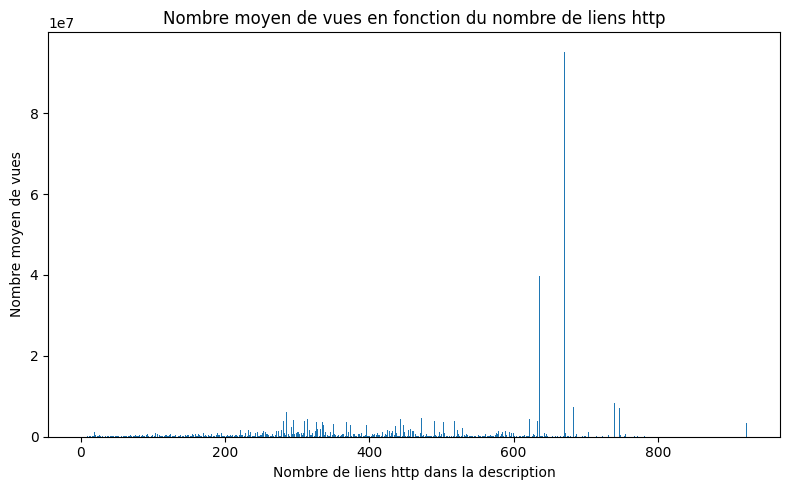

In [17]:
content = pd.read_csv ("dataset/train_val.csv")

content['nb_mots'] = content['description'].astype(str).apply(lambda x: len(x.split()))


content.to_csv("dataset/train_val.csv", index=False)

# Grouper par nombre de liens et calculer la somme ou la moyenne des vues
tableau = content.groupby('nb_mots')['views'].sum().reset_index()
print(tableau)

# Pour voir la moyenne des vues par nombre de liens :
tableau_moyenne = content.groupby('nb_mots')['views'].mean().reset_index()
print(tableau_moyenne)

# Crée un tableau matplotlib du nombre moyen de vues en fonction du nombre de liens http
plt.figure(figsize=(8, 5))
plt.bar(tableau_moyenne['nb_mots'], tableau_moyenne['views'])
plt.xlabel("Nombre de liens http dans la description")
plt.ylabel("Nombre moyen de vues")
plt.title("Nombre moyen de vues en fonction du nombre de liens http")
#plt.xticks(tableau_moyenne['nb_mots'])
plt.tight_layout()
plt.show()

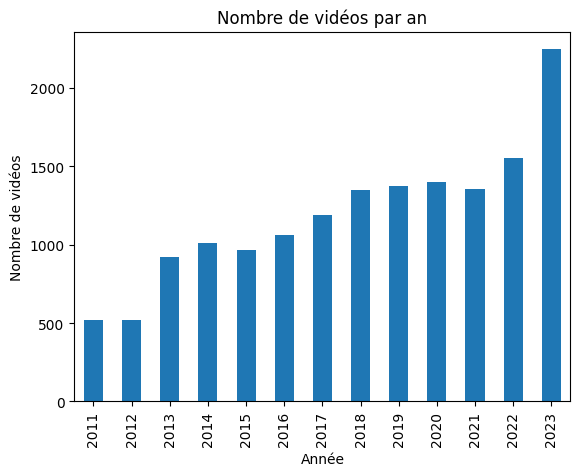

In [4]:
content['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Année')
plt.ylabel('Nombre de vidéos')
plt.title('Nombre de vidéos par an')
plt.show()


In [ ]:
nb_chain = content['channel'].nunique()
print(f"Nombre de chaînes uniques dans content : {nb_chain}")

Nombre de chaînes uniques dans content : 46


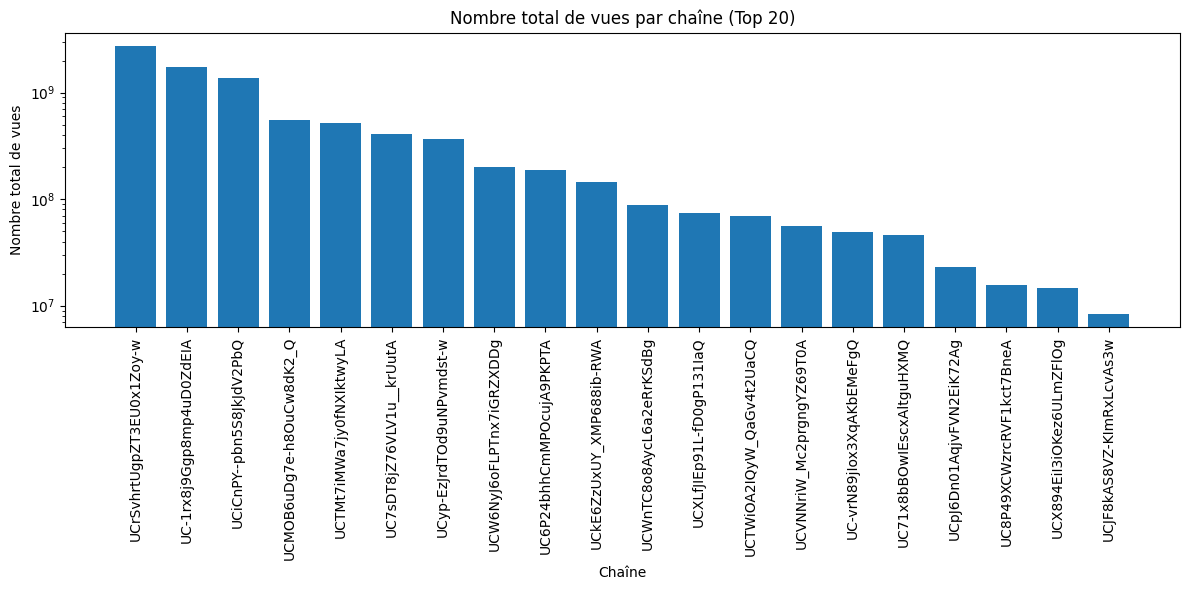

In [4]:
# Calculer le nombre total de vues par chaîne
vues_par_chaine_df = content.groupby('channel')['views'].sum().sort_values(ascending=False)

# Sélectionner les 20 premières chaînes
top_n = 20
top_channels = vues_par_chaine_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.bar(top_channels.index, top_channels.values)
plt.yscale('log')
plt.xlabel('Chaîne')
plt.ylabel('Nombre total de vues')
plt.title('Nombre total de vues par chaîne (Top 20)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [5]:
videos_par_chaine = content['channel'].value_counts()/ len(content)
print(videos_par_chaine)

channel
UC-1rx8j9Ggp8mp4uD0ZdEIA    0.327154
UCiCnPY--pbn5S8JkJdV2PbQ    0.143263
UCrSvhrtUgpZT3EU0x1Zoy-w    0.078672
UC6P24bhhCmMPOcujA9PKPTA    0.071761
UC7sDT8jZ76VLV1u__krUutA    0.058907
UCW6NyJ6oFLPTnx7iGRZXDDg    0.049800
UCMOB6uDg7e-h8OuCw8dK2_Q    0.049800
UCTMt7iMWa7jy0fNXIktwyLA    0.032489
UC71x8bBOwIEscxAltguHXMQ    0.028678
UCXLfJIEp91L-fD0gP131IaQ    0.028226
UC8P49XCWzrcRVF1kct7BneA    0.014275
UCKMV8axq3zTUmiyXav2Ytew    0.011110
UCyp-EzJrdTOd9uNPvmdst-w    0.010399
UCJF8kAS8VZ-KImRxLcvAs3w    0.010076
UCUrJu1fEq7kH9CBXaPH0PGw    0.007170
UCN5mdjo8Odux4PvR297-K4Q    0.006717
UCX894EiI3iOKez6ULmZFlOg    0.006395
UCHUnLXalwe66kBndfmH5cXA    0.005232
UCpa2QppVwCuivaWe5qfVY_Q    0.005038
UCpUhcwq3oB7HKvrNeQmxJsg    0.004974
UCVNNriW_Mc2prgngYZ69T0A    0.004715
UCFfovcqnybrMbIrNjyND-nA    0.004392
UCamfFGyiS8aGLBK4sQ661ew    0.004134
UCcRbWavyHkNsXdfot0yo8zw    0.003746
UC9DAY2JD9zy9zKA5OtwpNtw    0.003230
UCTWiOA2IQyW_QaGv4t2UaCQ    0.002390
UC2zrmdd_rWlMc2rAufX9bSg    0.

In [5]:
# Charger les chaînes uniques du fichier test.csv
test_content = pd.read_csv("dataset/test.csv")
test_channels = set(test_content['channel'].unique())

# Chaînes uniques dans train_val.csv (déjà chargé dans 'content')
train_val_channels = set(content['channel'].unique())

# Chaînes présentes dans test.csv mais pas dans train_val.csv
unique_test_channels = test_channels - train_val_channels

print(f"Nombre de chaînes dans test.csv qui ne sont pas dans train_val.csv : {len(unique_test_channels)}")

Nombre de chaînes dans test.csv qui ne sont pas dans train_val.csv : 0


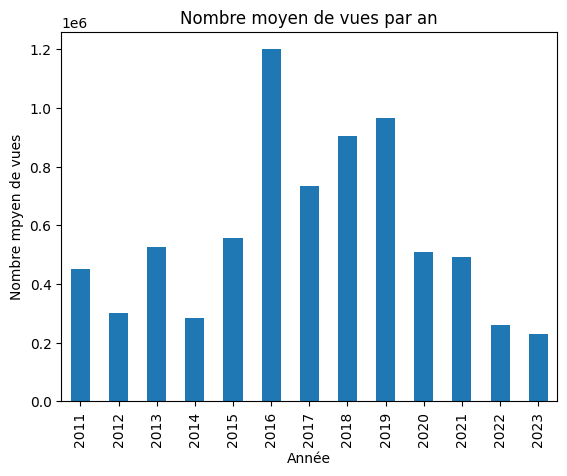

In [10]:

content.groupby('year')['views'].mean().sort_index().plot(kind='bar')
plt.xlabel('Année')
plt.ylabel('Nombre mpyen de vues')
plt.title('Nombre moyen de vues par an')
plt.show()


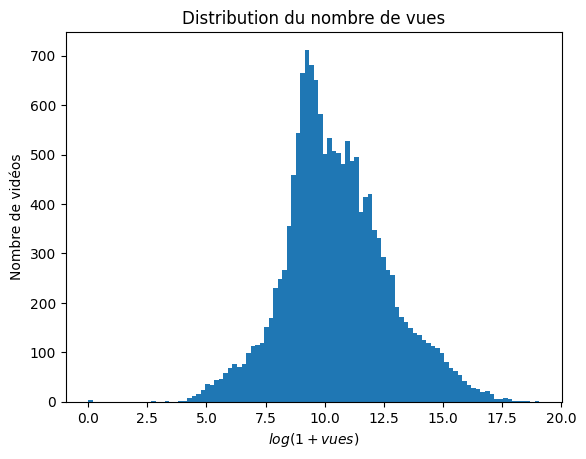

In [12]:
np.log1p(content['views']).plot(kind='hist', bins=100)
plt.xlabel('$log(1 +vues)$')
plt.ylabel('Nombre de vidéos')
plt.title('Distribution du nombre de vues')
plt.show()

In [4]:
proportion_2023 = (content['year'] == 2023).mean()
proportion_2022 = (content['year'] == 2022).mean()
print(f"Proportion de vidéos publiées en 2022 : {proportion_2022:.2%}")
print(f"Proportion de vidéos publiées en 2023 : {proportion_2023:.2%}")

Proportion de vidéos publiées en 2022 : 10.02%
Proportion de vidéos publiées en 2023 : 14.51%


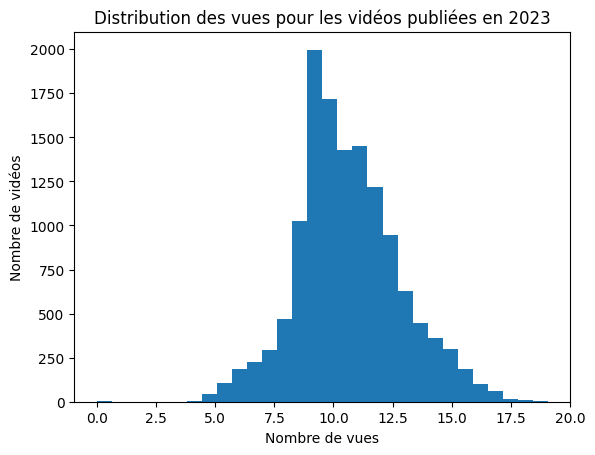

In [20]:
content_2023 = content[content['year'] != 2023]
content_2023['log1p_views'].plot(kind='hist', bins=30)
plt.xlabel('Nombre de vues')
plt.ylabel('Nombre de vidéos')
plt.title('Distribution des vues pour les vidéos publiées en 2023')
plt.show()

In [19]:
n_categories = 2
content['category'] = pd.qcut(content['log1p_views'], q=n_categories, labels=range(n_categories))
content['category'] = content['category'].astype(int)
print(content[['log1p_views', 'category']].head())

   log1p_views  category
0     9.417355         0
1     8.921991         0
2     9.378563         0
3     7.718241         0
4    11.642259         1


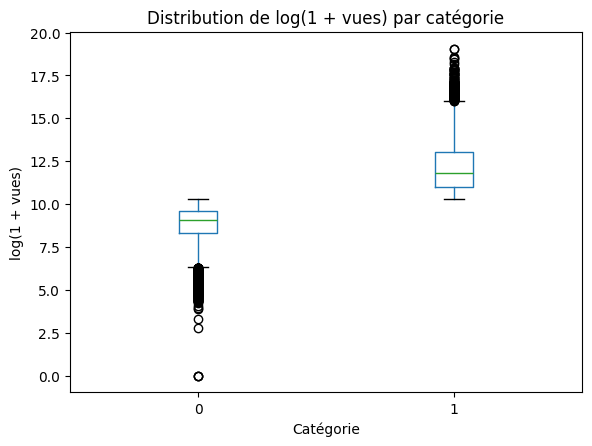

In [21]:
content.boxplot(column='log1p_views', by='category', grid=False)
plt.xlabel('Catégorie')
plt.ylabel('log(1 + vues)')
plt.title('Distribution de log(1 + vues) par catégorie')
plt.suptitle('')
plt.show()

In [22]:
content.to_csv("dataset/train_val.csv", index=False)

In [23]:
avg_var_log1pviews_per_category = content.groupby('category')['log1p_views'].agg(['mean', 'var']).reset_index()
avg_var_log1pviews_per_category.columns = ['category', 'avg_log1p_views', 'var_log1p_views']
print(avg_var_log1pviews_per_category)
avg_var_log1pviews_per_category.to_csv("dataset/log1pviews_per_category.csv", index=False)


   category  avg_log1p_views  var_log1p_views
0         0         8.778945         1.424623
1         1        12.214529         2.353662


In [21]:
videos_par_categorie = content['category'].value_counts().sort_index()
print(videos_par_categorie)

category
0    3097
1    3096
2    3096
3    3096
4    3097
Name: count, dtype: int64
